Curator: Jamaal Porchia

Reviewer: Ishan Prabhu

Title: A SIMPLE STOCHASTIC EPIDEMIOLOGICAL MODEL 

Pathogen: Covid-19

DOI: https://doi.org/10.26782/jmcms.2024.04.00006

Figure: 1

Outcome: Partial success was achieved because the shape was correct but the scale was not. The paper had inconsistent parameter definitions such as n defined as population and later used as number of days. The models output max was 1108, yet the paper's figure stated 1.48 million SI, creating inconsistencies. Also, change of time was unclear and I did not understand the simulation step count, seed, or randomness details, limiting reproducability.

Template required > 1 variable, thus dummy variable was added to satify template without changing model dynamic, allowing code to run correctly.

Notes: The figure was reproduced but there were scaling inconsistencies.

In [25]:
variable_names = [
    'X',
    'd'
]
"""Names of the variables in the SDE model. The order of the variables should be the same as the order of the drift and diffusion terms returned by the drift_term and diffusion_term functions."""

parameter_names = [
    'Lambda',
    'mu',
    'n'
]
"""Names of the parameters in the SDE model. The order of the parameters should be the same as the order of the values returned by the drift_term and diffusion_term functions."""

initial_values = dict(
    X=1.0,
    d=0.0
    
)
"""Dictionary of initial values for the variables in the SDE model. The keys should be the variable names in variable_names and the values should be the initial values for those variables."""

parameter_values = dict(

    Lambda=0.05,
    mu=0.0,
    n=1108.0
)
"""Dictionary of values for the parameters in the SDE model. The keys should be the parameter names in parameter_names and the values should be the values for those parameters."""

initial_time = 0.0
"""Initial time to simulate during testing and curation of the SDE model."""

final_time = 1.0
"""Final time to simulate during testing and curation of the SDE model."""


def drift_term(t, y, p):
    """The drift term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The drift term(s) of the SDE model in the same order as variable_names
    """
    X = y[0]

    lam = p[0]
    mu = p[1]
    n = p[2]

    return [
        lam * X * (n - X),
        0.0
    ]


def diffusion_term(t, y, p):
    """The diffusion term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The diffusion term(s) of the SDE model in the same order as variable_names
    """
    X = y[0]

    lam = p[0]
    mu = p[1]
    n = p[2]

    return [
        mu * X,
        0.0
    ]

# End Curation

# Begin Testing

*Do not modify anything below this cell.*

Successful implementations can execute the cells below in order without error to produce a figure.

## Do checks

In [26]:
missing_ics = [n for n in variable_names if n not in initial_values]
missing_params = [n for n in parameter_names if n not in parameter_values]

found_errors = False
if len(missing_ics) > 0:
    print(f"Error: Missing initial values for variables: {missing_ics}")
    found_errors = True
if len(missing_params) > 0:
    print(f"Error: Missing values for parameters: {missing_params}")
    found_errors = True
test_drift = drift_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
test_diffusion = diffusion_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
if len(test_drift) != len(variable_names):
    print(f"Error: The drift term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_drift)}.")
    found_errors = True
if len(test_diffusion) != len(variable_names):
    print(f"Error: The diffusion term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_diffusion)}.")
    found_errors = True
if found_errors:
    raise ValueError("Failed to define the SDE model.")

## Do simulation test

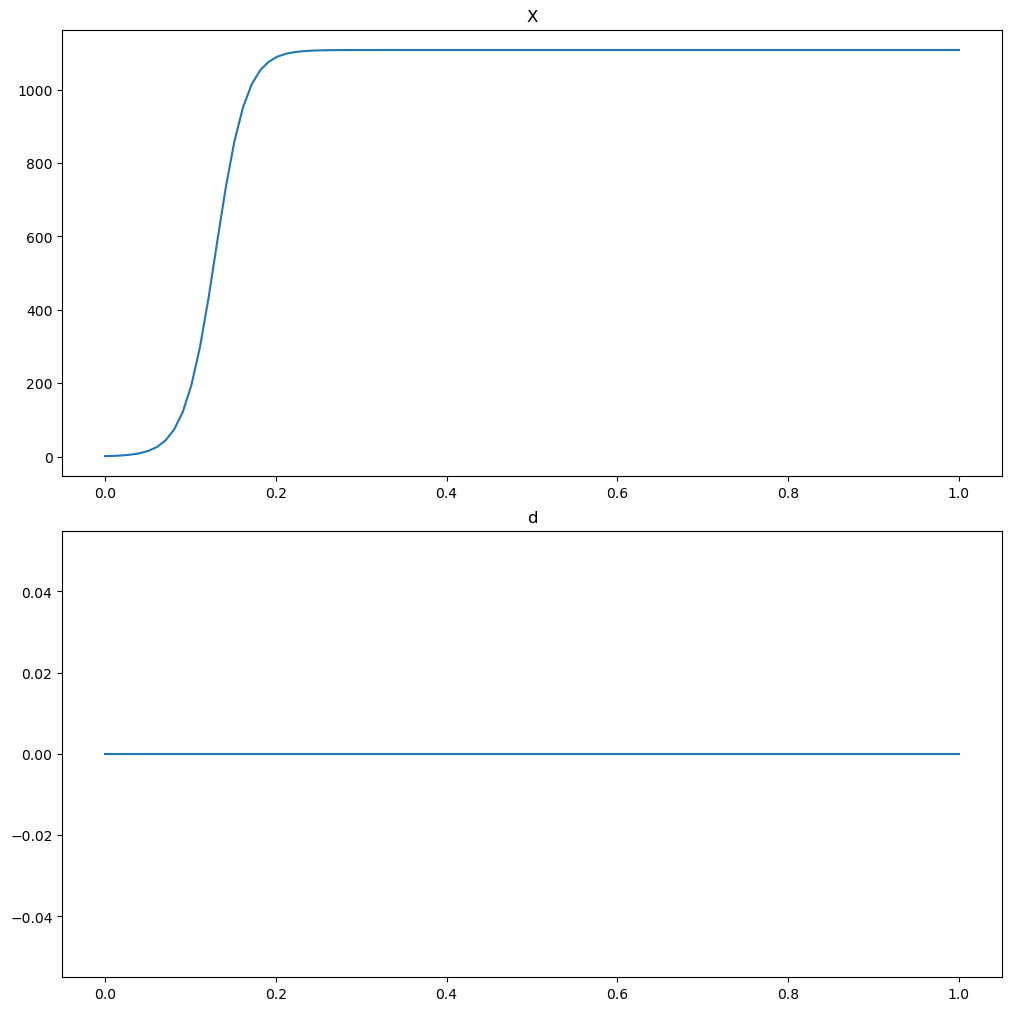

In [27]:
import diffrax
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

sim_times = np.linspace(initial_time, final_time, 100)
dt = (final_time - initial_time) / 1000
dr_term = diffrax.ODETerm(lambda t, y, p: jnp.array(drift_term(t, y, p)))
br_term = diffrax.VirtualBrownianTree(t0=initial_time, t1=final_time, tol=dt / 10, shape=(), key=jax.random.PRNGKey(0))
di_term = diffrax.ControlTerm(lambda t, y, p: jnp.array(diffusion_term(t, y, p)), br_term)
sde_terms = diffrax.MultiTerm(dr_term, di_term)
solver = diffrax.Euler()
solution = diffrax.diffeqsolve(
    sde_terms,
    solver,
    t0=initial_time,
    t1=final_time,
    dt0=dt,
    y0=jnp.asarray([initial_values[n] for n in variable_names]),
    args=jnp.asarray([parameter_values[n] for n in parameter_names]),
    saveat=diffrax.SaveAt(ts=jnp.asarray(sim_times)),
    max_steps=None,
    throw=True
).ys

fig, axs = plt.subplots(len(variable_names), 1, figsize=(10, 5 * len(variable_names)), layout="constrained")

for i, name in enumerate(variable_names):
    axs[i].plot(sim_times, solution[:, i])
    axs[i].set_title(name)

In [28]:
print('Sucessfully defined the SDE model and generated a test simulation plot.')

Sucessfully defined the SDE model and generated a test simulation plot.
